# 📊 Campaign Viability Analyzer — Data Audit & Cleaning Notebook
### Kickstarter Dataset | Project 4: Predictive Sales Analytics Engine

---

**Dataset:** Kickstarter Projects (ks-projects-201801.csv + ks-projects-201612.csv)  
**Goal:** Thoroughly audit both raw datasets, expose every data quality issue with visual proof, clean the data step-by-step, and produce a final pipeline-ready dataframe.

---

> **How to read this notebook:**  
> Every code cell is preceded by a markdown cell that explains:
> - **What** we are doing  
> - **Why** we are doing it  
> - **What to look for** in the output  

This notebook is the proof-of-work for all data decisions made before model building.


---
## Section 0 — Imports & Configuration

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Visual style ──────────────────────────────────────────────────────────────
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid",palette="deep",font_scale=1)

# ── Configuration ─────────────────────────────────────────────────────────────
CONFIG = {

# File paths
    'path_2018' : '../raw_dataset/ks-projects-201801.csv',
    'path_2016' : '../raw_dataset/ks-projects-201612.csv',

# Target
    'target_col': 'state',
    'valid_states'     : ['successful', 'failed'],   ## there are 4 more  we have to check now taking 2 for now 
    'target_map'       : {'successful': 1, 'failed': 0},

# Columns that CANNOT be used as features (post-campaign data)
    'leakage_cols'     : ['pledged', 'backers', 'usd pledged','usd_pledged_real', 'ID'],

# Safe feature columns (known at launch time)
    'text_col':'name',
    'numerical_cols':  ['usd_goal_real', 'campaign_duration_days','name_length', 'launch_year'],
'categorical_cols': ['category', 'main_category', 'currency', 'country','launch_month', 'launch_day_of_week'],

 # Date filters
    'min_launch_year'  : 2009,   # Kickstarter founded April 2009
    'min_duration_days': 0,      # 0-duration campaigns (deadline == launch date) retained after inspection — 92 rows, all verified as valid same-day campaigns
    'max_duration_days': 92,

# TF-IDF
# The dataset contains ~134K unique words, but ~66% appear only once and ~86%
# appear five times or fewer. Most of these rare words contribute little to
# generalization while significantly increasing dimensionality. We therefore
# start with the top 2,500 informative terms as a reasonable trade-off between
# model performance, memory usage, and training speed. This value can be tuned
# later during experimentation.
    'tfidf_max_features': 2500,  

# Model
    'test_size'   : 0.20,
    'cv_folds'    : 5,
    'random_state': 42,


    'name_length_bins': [0, 10, 20, 30, 40, 50, 60, 80, 100],
}


os.chdir(os.path.dirname(os.path.abspath('01_data_audit_and_cleaning.ipynb')))
os.makedirs('Plots', exist_ok=True)
os.makedirs('Data', exist_ok=True)
os.makedirs('Artifacts', exist_ok=True)


print("✅ Output directories ready.")
print("✅ Libraries loaded and CONFIG set.")
print(f"   Valid target states   : {CONFIG['valid_states']}")
print(f"   Leakage columns       : {CONFIG['leakage_cols']}")
print(f"   Min launch year       : {CONFIG['min_launch_year']}")
print(f"   Duration range (days) : {CONFIG['min_duration_days']} – {CONFIG['max_duration_days']}")

✅ Output directories ready.
✅ Libraries loaded and CONFIG set.
   Valid target states   : ['successful', 'failed']
   Leakage columns       : ['pledged', 'backers', 'usd pledged', 'usd_pledged_real', 'ID']
   Min launch year       : 2009
   Duration range (days) : 0 – 92


---
## Section 1 — Load Both Raw Datasets

**What:** Load `ks-projects-201801.csv` (2018) and `ks-projects-201612.csv` (2016) into separate DataFrames.  
**Why:** We have two versions of the same dataset. Before deciding which one to use, we must compare them on shape, columns, and data quality. We never assume a newer file is automatically better — we prove it.  
**What to look for:** Row counts, column names, and whether the 2016 file has any structural issues right out of the box.


In [2]:
# Load 2018 version
df_2018 = pd.read_csv(CONFIG['path_2018'], low_memory=False)

# Load 2016 version — requires latin-1 encoding (has special characters)
df_2016 = pd.read_csv(CONFIG['path_2016'], low_memory=False, encoding='latin-1') # utf-8 failed  encoding decoding error  

# The 2016 file has trailing spaces in every column name — strip them
df_2016.columns = df_2016.columns.str.strip()

print("=" * 55)
print("  2018 DATASET")
print("=" * 55)
print(f"  Rows    : {df_2018.shape[0]:,}")
print(f"  Columns : {df_2018.shape[1]}")
print(f"  Cols    : {df_2018.columns.tolist()}")

print()
print("=" * 55)
print("  2016 DATASET")
print("=" * 55)
print(f"  Rows    : {df_2016.shape[0]:,}")
print(f"  Columns : {df_2016.shape[1]}")
print(f"  Cols    : {df_2016.columns.tolist()}")


  2018 DATASET
  Rows    : 378,661
  Columns : 15
  Cols    : ['ID', 'name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'pledged', 'state', 'backers', 'country', 'usd pledged', 'usd_pledged_real', 'usd_goal_real']

  2016 DATASET
  Rows    : 323,750
  Columns : 17
  Cols    : ['ID', 'name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'pledged', 'state', 'backers', 'country', 'usd pledged', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']


---
## Section 2 — Comparing Both Datasets

**What:** A systematic side-by-side audit of the two files across four dimensions: (1) column differences, (2) state column health, (3) ID overlap, and (4) USD conversion quality.  
**Why:** We need hard evidence to decide whether to combine them, use one, or discard one. Every decision must be data-driven — not assumed.  
**What to look for:** Any columns present in one file but not the other, and whether the 2016 `state` column contains valid values.


In [3]:
# ── 2.1: Column Differences ───────────────────────────────────────────────────
cols_2016 = set(df_2016.columns)
cols_2018 = set(df_2018.columns)

only_in_2016 = cols_2016 - cols_2018
only_in_2018 = cols_2018 - cols_2016
in_both      = cols_2016 & cols_2018

print("── Column Audit ──────────────────────────────────────────")
print(f"  Columns in BOTH       : {sorted(in_both)}")
print(f"  Only in 2016          : {sorted(only_in_2016)}")
print(f"  Only in 2018          : {sorted(only_in_2018)}")


── Column Audit ──────────────────────────────────────────
  Columns in BOTH       : ['ID', 'backers', 'category', 'country', 'currency', 'deadline', 'goal', 'launched', 'main_category', 'name', 'pledged', 'state', 'usd pledged']
  Only in 2016          : ['Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']
  Only in 2018          : ['usd_goal_real', 'usd_pledged_real']


**Observation so far:**  
The 2016 dataset has 4 extra columns named `Unnamed: 13` through `Unnamed: 16`.  
The 2018 dataset has 2 additional columns: `usd_pledged_real` and `usd_goal_real` — corrected USD conversions.  
Let us inspect those unnamed columns next to understand what they actually contain.


In [4]:
# ── 2.2: Inspect the 4 unnamed columns in 2016 ──────────────────────────────
unnamed_cols = [c for c in df_2016.columns if 'Unnamed' in c]

print("── Unnamed Column Audit (2016 only) ─────────────────────")
for col in unnamed_cols:
    null_pct = df_2016[col].isnull().mean() * 100
    sample   = df_2016[col].dropna().head(5).tolist()
    print(f"  {col}")
    print(f"    Null rate : {null_pct:.1f}%")
    print(f"    Sample    : {sample}")
    print()


── Unnamed Column Audit (2016 only) ─────────────────────
  Unnamed: 13
    Null rate : 99.8%
    Sample    : ['504.94765278', '3984', '525', '0', '3035']

  Unnamed: 14
    Null rate : 100.0%
    Sample    : ['20', '0', '26', 'US', '1']

  Unnamed: 15
    Null rate : 100.0%
    Sample    : ['9854', '0', '0', 'US']

  Unnamed: 16
    Null rate : 100.0%
    Sample    : [25.0]



**Finding:** All 4 unnamed columns are over 99% null — they are leftover CSV formatting artifacts with no usable content. They will be discarded.  

Now let us check the most critical column — `state` — in the 2016 file.  
**Why this matters:** `state` is the source of our prediction target. If it is corrupted, the entire 2016 dataset becomes unusable.


In [5]:
print(df_2018["state"].unique())
print("=" *50)
print(df_2016["state"].unique())

['failed' 'canceled' 'successful' 'live' 'undefined' 'suspended']
['failed' 'canceled' 'successful' 'live' 'undefined' 'suspended' '4262'
 '3984' '525' '0' '3035' '3273' '590' '23924' '12306' '13675' '2' '4690'
 '4488.01' '687' '450' '16185' '80' '1495' '20' '14309.36'
 '2011-06-04 01:17:48' '8542' '3363' '950' '1800.5' '352' '1320' '18'
 '2161' '2016-06-28 21:36:59' '331' '17861' '1' '2630' '1085' '3711' '103'
 '8609.6' '312' '11044' '5600.65' '630' '1010' '178' '2530' '3671' '65'
 '5' '4451' '16' '2000' '377' '125' '6169' '90' '765' '218.5' '1850' '166'
 '2107' '63' '10' '3300' '306' '13' '400' '7703' '650' '800' '4287' '1056'
 '5940' '45' '1827' '10890.45' '245' '276' '200' '30' '6' '797' '6126'
 '175' '12201' '3605.13' '1200' '325' '2632' '7271' '46'
 '2016-02-18 21:40:23' '465' '9430.8' '2308' '310' '7470' '2759' '9857.8'
 '6453' '6189' '6093' '51' '860' '6442' '390' '1595' '1763.47' '130'
 '11315.5' '25' '3141' '218.75' '1700' '504' '641' '100' '2331' '763'
 '115' '255' '5656.43'

In [6]:
# ── 2.3: State Column Health Check ───────────────────────────────────────────
valid_states = ['failed', 'successful', 'canceled', 'live', 'undefined', 'suspended']

state_2018 = df_2018['state'].value_counts()
state_2016 = df_2016['state'].value_counts()

bad_state_rows_2016 = df_2016[~df_2016['state'].isin(valid_states)]
bad_state_count     = len(bad_state_rows_2016)

print("── 2018 State Distribution (clean baseline) ──────────────")
print(state_2018.to_string())

print()
print("── 2016 State Distribution (all unique values) ───────────")
print(f"  Total unique values in 2016 state column: {df_2016['state'].nunique()}")
print(f"  Rows with NON-STANDARD state values: {bad_state_count:,}")
print()
print("  Sample of invalid state values found in 2016:")
print(bad_state_rows_2016['state'].value_counts().head(15).to_string())


── 2018 State Distribution (clean baseline) ──────────────
state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846

── 2016 State Distribution (all unique values) ───────────
  Total unique values in 2016 state column: 410
  Rows with NON-STANDARD state values: 632

  Sample of invalid state values found in 2016:
state
0      96
1      15
5      11
25     11
10     10
100     8
50      7
65      6
20      5
35      5
2       5
55      5
110     5
21      4
30      4


**Critical Finding 🚨:**  
The 2016 `state` column contains numeric values like `0`, `1`, `5`, `25`, `100` in 632 rows.  
These are not valid campaign states — they are data corruption (possibly percentage values pasted into the wrong column).  
This alone makes the 2016 dataset unreliable as a source for our target variable.

Let us now check whether the 2016 dataset adds any unique campaigns not already in 2018.


In [7]:
# 2.4 : Campaign ID Overlap & Data Consistency Check

# ---------- Standardize ID columns ----------
df_2016["ID"] = df_2016["ID"].astype(str).str.strip()
df_2018["ID"] = df_2018["ID"].astype(str).str.strip()

# ---------- Create ID sets ----------
ids_2016 = set(df_2016["ID"])
ids_2018 = set(df_2018["ID"])

only_in_2016 = ids_2016 - ids_2018
only_in_2018 = ids_2018 - ids_2016
common_ids   = ids_2016 & ids_2018

# ---------- Basic overlap statistics ----------
print("=" * 65)
print("CAMPAIGN ID OVERLAP ANALYSIS")
print("=" * 65)

print(f"2016 Unique Campaign IDs : {len(ids_2016):,}")
print(f"2018 Unique Campaign IDs : {len(ids_2018):,}")
print(f"Shared Campaign IDs      : {len(common_ids):,}")
print(f"Only in 2016             : {len(only_in_2016):,}")
print(f"Only in 2018             : {len(only_in_2018):,}")

# ---------- Check if merging adds new campaigns ----------
if len(only_in_2016) == 0:
    print("\n✅ Every campaign from the 2016 dataset already exists in the 2018 dataset.")
    print("   Merging both datasets will NOT increase the number of campaigns.")
else:
    print(f"\n⚠️  {len(only_in_2016):,} campaigns exist only in the 2016 dataset.")

# Verify overlapping records

print("\n" + "=" * 65)
print("VERIFYING OVERLAPPING RECORDS")
print("=" * 65)

common_2016 = (df_2016[df_2016["ID"].isin(common_ids)].sort_values("ID"))

common_2018 = (df_2018[df_2018["ID"].isin(common_ids)].sort_values("ID"))

merged = common_2016.merge(common_2018,on="ID",suffixes=("_2016", "_2018"))

# Columns expected to match
columns_to_compare = ["name","category","main_category","currency","country","state",]

for col in columns_to_compare:

    diff = (merged[f"{col}_2016"].fillna("").astype(str).str.strip() != merged[f"{col}_2018"].fillna("").astype(str).str.strip())

    mismatch_count = diff.sum()

    print(f"{col:<15}: {mismatch_count:,} mismatches")

print("\n✅ ID overlap verification completed.")

CAMPAIGN ID OVERLAP ANALYSIS
2016 Unique Campaign IDs : 323,750
2018 Unique Campaign IDs : 378,661
Shared Campaign IDs      : 323,750
Only in 2016             : 0
Only in 2018             : 54,911

✅ Every campaign from the 2016 dataset already exists in the 2018 dataset.
   Merging both datasets will NOT increase the number of campaigns.

VERIFYING OVERLAPPING RECORDS
name           : 4,263 mismatches
category       : 631 mismatches
main_category  : 444 mismatches
currency       : 632 mismatches
country        : 4,422 mismatches
state          : 5,058 mismatches

✅ ID overlap verification completed.


**Final Verdict on Dataset Combination:**

| Check | 2016 File | 2018 File |
|---|---|---|
| Row count | 323,750 | 378,661 |
| Column names | Trailing spaces on all names | Clean |
| Extra columns | 4 unnamed garbage columns | None |
| `state` corruption | 632 rows with numeric values | Zero corruption |
| USD conversion | Old method only (`usd pledged`) | Corrected (`usd_goal_real`, `usd_pledged_real`) |
| Unique campaigns not in 2018 | **0** | — |

**Decision: Use only `ks-projects-201801.csv` (2018).** The 2016 file adds no new campaigns, introduces corrupt state values, and has inferior USD conversion columns. Combining would only add noise.

All further work proceeds with `df_2018` only.


In [8]:
df_2018.to_csv("data/kickstarter_raw.csv", index=False)

print("✅ Dataset saved to data/kickstarter_raw.csv")

✅ Dataset saved to data/kickstarter_raw.csv


In [9]:
# Save the selected dataset for the rest of the project
df_2018.to_csv("data/kickstarter_raw.csv", index=False)

# Update CONFIG to use the working dataset from now on
CONFIG["raw_data_path"] = "data/kickstarter_raw.csv"

print("✅ Working dataset saved.")
print(f"Dataset path updated to: {CONFIG['raw_data_path']}")

✅ Working dataset saved.
Dataset path updated to: data/kickstarter_raw.csv


---
## Section 3 — Raw Data Audit (2018 Dataset)

**What:** A full inspection of the 2018 dataset as-is, before any cleaning. We check shape, dtypes, nulls, and every column's content.  
**Why:** You must understand what you are working with before touching anything. Cleaning without auditing is guessing.  
**What to look for:** Missing values, wrong data types (dates stored as strings), and columns that look fine but contain trap values.


In [10]:
# Work on the 2018 dataset from here onward
df = df_2018.copy()

print("── Raw Shape ─────────────────────────────────────────────")
print(f"  Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

print()
print("── Data Types ────────────────────────────────────────────")
print(df.dtypes.to_string())

print()
print("── Null Count per Column ─────────────────────────────────")
nulls = df.isnull().sum()
for col, n in nulls.items():
    flag = ' ⚠️' if n > 0 else ' ✅'
    print(f"  {col:<22} {n:>6,} nulls{flag}")


── Raw Shape ─────────────────────────────────────────────
  Rows: 378,661   Columns: 15

── Data Types ────────────────────────────────────────────
ID                   object
name                 object
category             object
main_category        object
currency             object
deadline             object
goal                float64
launched             object
pledged             float64
state                object
backers               int64
country              object
usd pledged         float64
usd_pledged_real    float64
usd_goal_real       float64

── Null Count per Column ─────────────────────────────────
  ID                          0 nulls ✅
  name                        4 nulls ⚠️
  category                    0 nulls ✅
  main_category               0 nulls ✅
  currency                    0 nulls ✅
  deadline                    0 nulls ✅
  goal                        0 nulls ✅
  launched                    0 nulls ✅
  pledged                     0 nulls ✅
  state   

In [11]:
# ── First 5 rows — visual sanity check ───────────────────────────────────────
print("── First 5 Rows ──────────────────────────────────────────")
df.head()

── First 5 Rows ──────────────────────────────────────────


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09,1000.0,2015-08-11 12:12:28,0.0,failed,0,GB,0.0,0.0,1533.95
1,1000003930,Greeting From Earth: ZGAC Arts Capsule For ET,Narrative Film,Film & Video,USD,2017-11-01,30000.0,2017-09-02 04:43:57,2421.0,failed,15,US,100.0,2421.0,30000.00
2,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26,45000.0,2013-01-12 00:20:50,220.0,failed,3,US,220.0,220.0,45000.00
3,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16,5000.0,2012-03-17 03:24:11,1.0,failed,1,US,1.0,1.0,5000.00
4,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29,19500.0,2015-07-04 08:35:03,1283.0,canceled,14,US,1283.0,1283.0,19500.00


In [12]:
# ── Shape — visual sanity check ───────────────────────────────────────
print("── Shape ──────────────────────────────────────────")
df.shape

── Shape ──────────────────────────────────────────


(378661, 15)

In [13]:
# ── All Columns — visual sanity check ───────────────────────────────────────
print("── Columns ──────────────────────────────────────────")
df.columns.tolist()

── Columns ──────────────────────────────────────────


['ID',
 'name',
 'category',
 'main_category',
 'currency',
 'deadline',
 'goal',
 'launched',
 'pledged',
 'state',
 'backers',
 'country',
 'usd pledged',
 'usd_pledged_real',
 'usd_goal_real']

In [14]:
# ── Leakage Column Analysis ──────────────────────────────────────────────────
leakage_info = {
    'pledged'         : 'Total money raised — only known AFTER campaign ends',
    'backers'         : 'Number of supporters — only known AFTER campaign ends',
    'usd pledged'     : 'Old USD conversion of pledged — same leak, different unit',
    'usd_pledged_real': 'Corrected USD conversion of pledged — still a leak',
    'ID'              : 'Random identifier — zero predictive signal',
}

safe_info = {
    'name'            : '✅ Campaign title — known at launch',
    'category'        : '✅ Campaign category — known at launch',
    'main_category'   : '✅ Broad category — known at launch',
    'currency'        : '✅ Currency used — known at launch',
    'goal'            : '✅ Funding goal set by creator — known at launch',
    'usd_goal_real'   : '✅ Goal in USD — derived from goal+currency, known at launch',
    'launched'        : '✅ Launch date — known at launch (it IS the launch)',
    'deadline'        : '✅ End date — set at launch by creator',
    'country'         : '✅ Creator country — known at launch',
}

print("── 🚨 LEAKAGE COLUMNS (must be removed) ─────────────────")
for col, reason in leakage_info.items():
    present = '✅ Present' if col in df.columns else '❌ Not found'
    print(f"  [{present}]  {col:<22} — {reason}")

print()
print("── ✅ SAFE FEATURE COLUMNS ───────────────────────────────")
for col, reason in safe_info.items():
    print(f"  {reason:<45} ({col})")

# Show what percentage of rows have non-null leakage data
print()
print("── Leakage Column Non-Null Rates ─────────────────────────")
for col in leakage_info:
    if col in df.columns:
        non_null = df[col].notnull().mean() * 100
        print(f"  {col:<22}  {non_null:.1f}% non-null  ← this data exists and will corrupt your model")


── 🚨 LEAKAGE COLUMNS (must be removed) ─────────────────
  [✅ Present]  pledged                — Total money raised — only known AFTER campaign ends
  [✅ Present]  backers                — Number of supporters — only known AFTER campaign ends
  [✅ Present]  usd pledged            — Old USD conversion of pledged — same leak, different unit
  [✅ Present]  usd_pledged_real       — Corrected USD conversion of pledged — still a leak
  [✅ Present]  ID                     — Random identifier — zero predictive signal

── ✅ SAFE FEATURE COLUMNS ───────────────────────────────
  ✅ Campaign title — known at launch            (name)
  ✅ Campaign category — known at launch         (category)
  ✅ Broad category — known at launch            (main_category)
  ✅ Currency used — known at launch             (currency)
  ✅ Funding goal set by creator — known at launch (goal)
  ✅ Goal in USD — derived from goal+currency, known at launch (usd_goal_real)
  ✅ Launch date — known at launch (it IS the launch) (

In [15]:
# ── Drop leakage columns ─────────────────────────────────────────────────────
cols_before = df.shape[1]
df.drop(columns=CONFIG['leakage_cols'], inplace=True)
cols_after  = df.shape[1]

print(f"  Columns before leakage drop : {cols_before}")
print(f"  Columns after leakage drop  : {cols_after}")
print(f"  Columns removed             : {cols_before - cols_after}")
print(f"  Remaining columns           : {df.columns.tolist()}")


  Columns before leakage drop : 15
  Columns after leakage drop  : 10
  Columns removed             : 5
  Remaining columns           : ['name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'state', 'country', 'usd_goal_real']


---
## Section 5 — Target Variable: The `state` Column

**What:** Inspect the distribution of the `state` column and convert it to a binary target (1 = successful, 0 = failed).  
**Why:** Our model is a binary classifier — it predicts one of two outcomes. The `state` column currently has 6 values.  
- `successful` → **1** (the outcome we want to predict)
- `failed` → **0** (the other outcome)
- `canceled`, `live`, `undefined`, `suspended` 

Canceled campaigns are ambiguous — the creator chose to stop, not that the market rejected them. Including them as "failed" would mislabel data. We drop them to keep our target clean and unambiguous.

**What to look for:** The class balance after filtering. If 95%+ rows are one class, we have an imbalance problem requiring special handling.


In [16]:
df['state'].value_counts()

state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846
Name: count, dtype: int64

In [17]:
print(df.columns.tolist())

['name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'state', 'country', 'usd_goal_real']


**What:** Confirm which columns remain after dropping leakage columns.  
**Why:** Before moving forward, we verify that all 5 leakage columns are gone and only safe features remain. A silent failure here — where a leakage column wasn't dropped correctly — would corrupt every step that follows.  
**What to look for:** No `pledged`, `backers`, `usd pledged`, `usd_pledged_real`, or `ID` in the list.

state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846
Name: count, dtype: int64

Rows Removed : 46,986 (12.41%)
Rows Kept    : 331,675


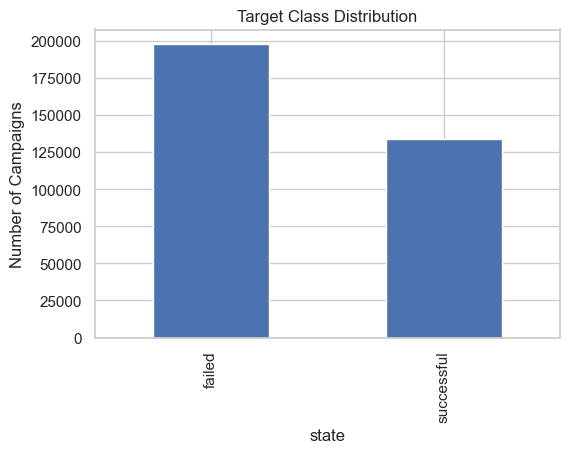

In [18]:
state_counts = df["state"].value_counts()

keep_mask = df["state"].isin(CONFIG["valid_states"])

rows_removed = (~keep_mask).sum()
rows_kept = keep_mask.sum()

print(state_counts)
print()

print(f"Rows Removed : {rows_removed:,} ({rows_removed/len(df)*100:.2f}%)")
print(f"Rows Kept    : {rows_kept:,}")

plt.figure(figsize=(6,4))
df.loc[keep_mask, "state"].value_counts().plot(kind="bar")
plt.title("Target Class Distribution")
plt.ylabel("Number of Campaigns")
plt.savefig("plots/01_target_distribution.png", dpi=150)
plt.show()

In [19]:
# ── Apply state filter and create binary target ───────────────────────────────
df = df[df[CONFIG['target_col']].isin(CONFIG['valid_states'])].copy()
df['target'] = df[CONFIG['target_col']].map(CONFIG['target_map'])

success_rate = df['target'].mean()
print(f"  Final dataset shape : {df.shape}")
print(f"  Success rate        : {success_rate:.2%}")
print(f"  Failure rate        : {1-success_rate:.2%}")
print()
if success_rate < 0.10 or success_rate > 0.90:
    print("  ⚠️  Class imbalance detected. Will use class_weight='balanced' in model.")
else:
    print("  ✅ Class balance is acceptable for standard training.")


  Final dataset shape : (331675, 11)
  Success rate        : 40.39%
  Failure rate        : 59.61%

  ✅ Class balance is acceptable for standard training.


---
## Section 6 — Date Column Audit

**What:** Parse `launched` and `deadline` from strings to proper datetime objects, then check for corrupted date values.  
**Why:** Dates stored as strings cannot be used for math operations. We need them as datetime objects to calculate `campaign_duration_days`.  
The dataset is known to contain a `1970-01-01` launch date — a Unix epoch artifact. Unix timestamps count seconds from January 1, 1970. A failed timestamp conversion produces this date.  
Kickstarter was founded in **April 2009** — any campaign with a launch date before 2009 is provably corrupt.

**What to look for:** Rows with launch year < 2009 (impossible), and campaign durations that exceed 92 days (Kickstarter's maximum is 60 days — we allow slight buffer for edge cases).


In [20]:
# ── Parse dates ─────────────────────────────────────────────────────────────
df['launched'] = pd.to_datetime(df['launched'], errors='coerce')
df['deadline'] = pd.to_datetime(df['deadline'], errors='coerce')

print("── Date Range (before filtering) ─────────────────────────")
print(f"  Launched : {df['launched'].min()}  →  {df['launched'].max()}")
print(f"  Deadline : {df['deadline'].min()}  →  {df['deadline'].max()}")

print()
corrupt_dates = df[df['launched'].dt.year < CONFIG['min_launch_year']]
print(f"  ⚠️  Rows with launch year < {CONFIG['min_launch_year']} (corrupt): {len(corrupt_dates):,}")
print()
print("  Sample corrupt rows:")
print(corrupt_dates[['name', 'launched', 'deadline', 'state']].head(5).to_string())


── Date Range (before filtering) ─────────────────────────
  Launched : 2009-04-21 21:02:48  →  2017-12-29 03:22:32
  Deadline : 2009-05-03 00:00:00  →  2018-01-02 00:00:00

  ⚠️  Rows with launch year < 2009 (corrupt): 0

  Sample corrupt rows:
Empty DataFrame
Columns: [name, launched, deadline, state]
Index: []


In [21]:

df['launch_month']       = df['launched'].dt.month
df['launch_day_of_week'] = df['launched'].dt.dayofweek
df['launch_year']        = df['launched'].dt.year

In [22]:
# ── Remove corrupt dates ──────────────────────────────────────────────────────
rows_before = len(df)

# Keep only campaigns launched in or after Kickstarter's founding year
df = df[df["launched"].dt.year >= CONFIG["min_launch_year"]].copy()

rows_after = len(df)
rows_removed = rows_before - rows_after

print("=" * 60)
print("REMOVE INVALID LAUNCH DATES")
print("=" * 60)

print(f"Rows before cleaning : {rows_before:,}")
print(f"Rows removed         : {rows_removed:,} ({rows_removed/rows_before:.2%})")
print(f"Rows remaining       : {rows_after:,}")

REMOVE INVALID LAUNCH DATES
Rows before cleaning : 331,675
Rows removed         : 0 (0.00%)
Rows remaining       : 331,675


---
## Section 7 — Engineering `campaign_duration_days`

**What:** Calculate the number of days each campaign ran (from `launched` to `deadline`) and filter out impossible durations.  
**Why:** Campaign duration is a real business signal. A creator who runs a 5-day campaign is behaving very differently from one who runs a 60-day campaign. We engineer this as a feature.  
However, raw duration has extreme outliers — durations of 16,000+ days exist in the data (roughly 45 years). These are clearly data entry errors.  
Kickstarter's official maximum campaign length is **60 days**. We set our filter ceiling at **92 days** to account for any platform edge cases or API rounding artifacts.

**What to look for:** The duration distribution plot showing the outliers, and how many rows get removed.


In [23]:
# Calculate campaign duration
df["campaign_duration_days"] = (
    df["deadline"] - df["launched"]
).dt.days

print("── Duration Statistics ─────────────────────────────")
print(df["campaign_duration_days"].describe().round(1).to_string())

# Find invalid durations
invalid_duration_rows = df[
    (df["campaign_duration_days"] < CONFIG["min_duration_days"]) |
    (df["campaign_duration_days"] > CONFIG["max_duration_days"])
]

print()
print("── Invalid Duration Rows ───────────────────────────")
print(f"Total invalid rows: {len(invalid_duration_rows):,}")

print(
    invalid_duration_rows[
        ["name", "launched", "deadline", "campaign_duration_days"]
    ].head(8).to_string(index=False)
)

── Duration Statistics ─────────────────────────────
count    331675.0
mean         33.0
std          12.7
min           0.0
25%          29.0
50%          29.0
75%          35.0
max          91.0

── Invalid Duration Rows ───────────────────────────
Total invalid rows: 0
Empty DataFrame
Columns: [name, launched, deadline, campaign_duration_days]
Index: []


**What:** Inspect campaigns where `campaign_duration_days == 0` — meaning deadline and launch date are the same.  
**Why:** Zero-duration campaigns are suspicious. Before deciding to keep or remove them, we examine them directly. If they are clearly corrupt entries (e.g., test uploads, placeholder campaigns), they should be filtered. If they appear to be valid same-day campaigns, they can be retained.  
**What to look for:** Do the launched and deadline timestamps look realistic? Are these real campaigns or obvious data entry errors?

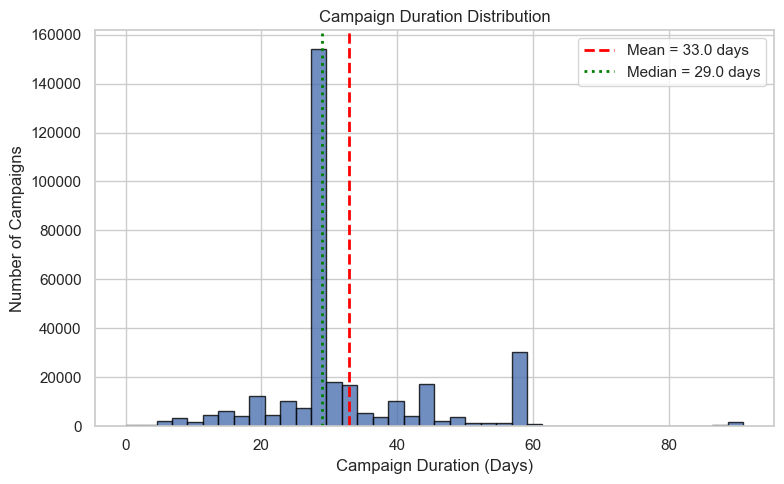

Mean Duration   : 32.95 days
Median Duration : 29.00 days
Minimum         : 0 days
Maximum         : 91 days


In [24]:
plt.figure(figsize=(8,5))

plt.hist(
    df["campaign_duration_days"],
    bins=40,
    edgecolor="black",
    alpha=0.8
)

# Mean
plt.axvline(
    df["campaign_duration_days"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {df['campaign_duration_days'].mean():.1f} days"
)

# Median
plt.axvline(
    df["campaign_duration_days"].median(),
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"Median = {df['campaign_duration_days'].median():.1f} days"
)

plt.title("Campaign Duration Distribution")
plt.xlabel("Campaign Duration (Days)")
plt.ylabel("Number of Campaigns")

plt.legend()

plt.tight_layout()
plt.savefig("plots/02_duration_distribution.png", dpi=150)
plt.show()
print(f"Mean Duration   : {df['campaign_duration_days'].mean():.2f} days")
print(f"Median Duration : {df['campaign_duration_days'].median():.2f} days")
print(f"Minimum         : {df['campaign_duration_days'].min()} days")
print(f"Maximum         : {df['campaign_duration_days'].max()} days")

In [25]:
# ── Apply duration filter ────────────────────────────────────────────────────
# campaign_duration_days is calculated using `.dt.days`, which returns the
# number of complete days. Campaigns lasting less than 24 hours therefore
# appear as 0 days and are treated as valid.

rows_before = len(df)

# Keep campaigns within the valid duration range
df = df[
    df["campaign_duration_days"].between(
        CONFIG["min_duration_days"],
        CONFIG["max_duration_days"]
    )
].copy()

rows_after = len(df)
rows_removed = rows_before - rows_after

print("=" * 60)
print("CAMPAIGN DURATION FILTER")
print("=" * 60)

print(f"Rows before filtering : {rows_before:,}")
print(f"Rows removed          : {rows_removed:,} ({rows_removed / rows_before:.2%})")
print(f"Rows remaining        : {rows_after:,}")

print("\nDuration Statistics (After Filtering)")
print("-" * 60)
print(df["campaign_duration_days"].describe().round(1).to_string())

# Final verification
assert (
    df["campaign_duration_days"]
    .between(CONFIG["min_duration_days"], CONFIG["max_duration_days"])
    .all()
), "❌ Invalid campaign durations still exist after filtering."

print("\n✅ Duration filtering completed successfully.")

CAMPAIGN DURATION FILTER
Rows before filtering : 331,675
Rows removed          : 0 (0.00%)
Rows remaining        : 331,675

Duration Statistics (After Filtering)
------------------------------------------------------------
count    331675.0
mean         33.0
std          12.7
min           0.0
25%          29.0
50%          29.0
75%          35.0
max          91.0

✅ Duration filtering completed successfully.


---
## Section 8 — Text Feature Audit: `name` Column

**What:** Inspect the campaign title (`name`) for nulls, length distribution, and basic quality issues.  
**Why:** The `name` column is our only text feature — it will be converted into a TF-IDF matrix later. Null names cannot be vectorized and must be handled. Very short names (1–2 characters) are likely placeholder entries. Understanding the length distribution tells us whether `name_length` is a useful feature.

**What to look for:** Null count, length distribution, and suspiciously short or long titles.


In [26]:

SHORT_NAME_THRESHOLD = 5

# Check for missing project names
null_names = df["name"].isna().sum()

print("=" * 60)
print("PROJECT NAME AUDIT")
print("=" * 60)

print(f"Missing project names : {null_names:,}")

# Fill missing values only if they exist
if null_names > 0:
    df["name"] = df["name"].fillna("")
    print("✅ Missing names replaced with empty strings.")
else:
    print("✅ No missing project names found.")

# Create name_length feature
df["name_length"] = df["name"].str.len()

print("\nName Length Statistics")
print("-" * 60)
print(df["name_length"].describe().round(1).to_string())

# Inspect unusually short names
short_names = df[
    df["name_length"] < SHORT_NAME_THRESHOLD
][["name", "name_length", "target"]]

print(f"\nVery Short Names (< {SHORT_NAME_THRESHOLD} characters)")
print("-" * 60)
print(f"Total very short names : {len(short_names):,}")

print(short_names.head(10).to_string(index=False))

PROJECT NAME AUDIT
Missing project names : 3
✅ Missing names replaced with empty strings.

Name Length Statistics
------------------------------------------------------------
count    331675.0
mean         34.2
std          16.0
min           0.0
25%          21.0
50%          33.0
75%          48.0
max          85.0

Very Short Names (< 5 characters)
------------------------------------------------------------
Total very short names : 1,157
name  name_length  target
Ropw            4       0
High            4       0
 Lei            3       1
 ONE            3       0
Nelo            4       1
iRoo            4       0
Tiem            4       0
  HI            2       0
Finn            4       0
 XXX            3       0


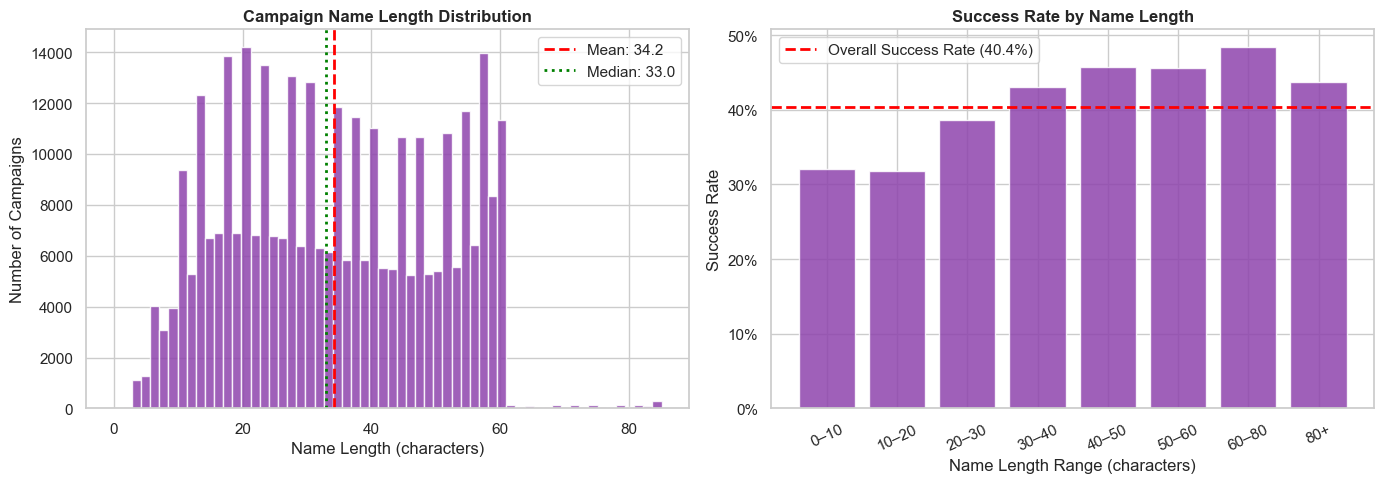

In [27]:
# =============================================================================
# Campaign Name Length Analysis
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------------------------------------------------
# Left: Name Length Distribution
# -------------------------------------------------------------------------
axes[0].hist(
    df["name_length"],
    bins=60,
    color="#8e44ad",
    edgecolor="white",
    alpha=0.85
)

axes[0].axvline(
    df["name_length"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df['name_length'].mean():.1f}"
)

axes[0].axvline(
    df["name_length"].median(),
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"Median: {df['name_length'].median():.1f}"
)

axes[0].set_title(
    "Campaign Name Length Distribution",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_xlabel("Name Length (characters)")
axes[0].set_ylabel("Number of Campaigns")
axes[0].legend()

# -------------------------------------------------------------------------
# Right: Success Rate by Name Length
# -------------------------------------------------------------------------
labels = [
    "0–10",
    "10–20",
    "20–30",
    "30–40",
    "40–50",
    "50–60",
    "60–80",
    "80+"
]

name_bins = pd.cut(
    df["name_length"],
    bins=CONFIG["name_length_bins"]
)

success_by_len = (
    df.groupby(name_bins, observed=True)["target"]
      .mean()
)

axes[1].bar(
    range(len(success_by_len)),
    success_by_len.values,
    color="#8e44ad",
    edgecolor="white",
    alpha=0.85
)

axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=25)

axes[1].set_title(
    "Success Rate by Name Length",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel("Name Length Range (characters)")
axes[1].set_ylabel("Success Rate")

axes[1].yaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)

axes[1].axhline(
    df["target"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall Success Rate ({df['target'].mean():.1%})"
)

axes[1].legend()

plt.tight_layout()
plt.savefig("plots/03_name_length_analysis.png", dpi=150)
plt.show()

---
## Section 9 — Numerical Feature Audit: `usd_goal_real` and `campaign_duration_days`

**What:** Inspect the distribution and outliers in our two primary numerical features.  
**Why:** Tree models and logistic regression both benefit from understanding the scale and skew of numerical inputs. Extreme outliers in funding goals (e.g., a $100M goal on a crowdfunding platform) are likely test entries or jokes — they skew the StandardScaler and damage model performance.  

`usd_goal_real` is the preferred goal column because it normalizes all currencies to USD using accurate historical exchange rates — unlike the raw `goal` column which mixes GBP, EUR, USD, etc.

**What to look for:** Right-skewed distributions with extreme outliers, and whether those outliers follow a realistic business pattern.


In [28]:
# ── Apply duration filter ────────────────────────────────────────────────────
# campaign_duration_days is calculated using `.dt.days`, which returns the
# number of complete days. Campaigns lasting less than 24 hours therefore
# appear as 0 days and are treated as valid.

rows_before = len(df)

# Keep campaigns within the valid duration range
df = df[
    df["campaign_duration_days"].between(
        CONFIG["min_duration_days"],
        CONFIG["max_duration_days"]
    )
].copy()

rows_after = len(df)
rows_removed = rows_before - rows_after

print("=" * 60)
print("CAMPAIGN DURATION FILTER")
print("=" * 60)

print(f"Rows before filtering : {rows_before:,}")
print(f"Rows removed          : {rows_removed:,} ({rows_removed / rows_before:.2%})")
print(f"Rows remaining        : {rows_after:,}")

print("\nDuration Statistics (After Filtering)")
print("-" * 60)
print(df["campaign_duration_days"].describe().round(1).to_string())

# Final verification
assert (
    df["campaign_duration_days"]
    .between(CONFIG["min_duration_days"], CONFIG["max_duration_days"])
    .all()
), "❌ Invalid campaign durations still exist after filtering."

print("\n✅ Duration filtering completed successfully.")

CAMPAIGN DURATION FILTER
Rows before filtering : 331,675
Rows removed          : 0 (0.00%)
Rows remaining        : 331,675

Duration Statistics (After Filtering)
------------------------------------------------------------
count    331675.0
mean         33.0
std          12.7
min           0.0
25%          29.0
50%          29.0
75%          35.0
max          91.0

✅ Duration filtering completed successfully.


In [29]:
# ── Goal distribution ────────────────────────────────────────────────────────
print("── usd_goal_real Stats ───────────────────────────────────")
print(df['usd_goal_real'].describe().apply(lambda x: f'{x:,.2f}').to_string())

print()
print("── Extreme Outliers (goal > $1M) ────────────────────────")
high_goal = df[df['usd_goal_real'] > 1_000_000]
print(f"  Rows with goal > $1M : {len(high_goal):,}")
print(high_goal[['name', 'usd_goal_real', 'currency', 'state']].head(10).to_string())


── usd_goal_real Stats ───────────────────────────────────
count        331,675.00
mean          41,510.00
std        1,108,929.66
min                0.01
25%            2,000.00
50%            5,000.00
75%           15,000.00
max      166,361,390.71

── Extreme Outliers (goal > $1M) ────────────────────────
  Rows with goal > $1M : 840
                                                       name  usd_goal_real currency   state
340                                          You in a novel     1076403.09      EUR  failed
971                              Maori MBT Awareness Centre     1600768.37      CAD  failed
1042                                 The Old Soul of a Lion     3000000.00      USD  failed
1144                                The Million Pound Shirt     1505185.36      GBP  failed
1795                                          ** GOLIATH **     3575408.62      CAD  failed
2920                                           Thermal Safe     2000000.00      USD  failed
2993             

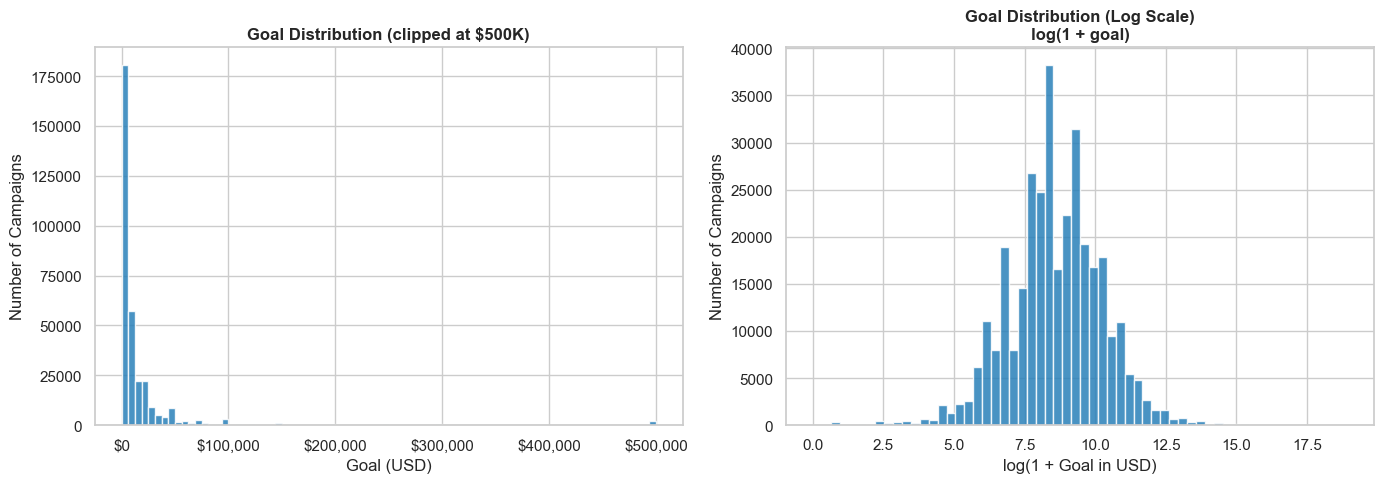

In [30]:
# ── Plot goal distribution (log scale) ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw distribution (clipped for visibility)
axes[0].hist(df['usd_goal_real'].clip(upper=500_000), bins=80,
             color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].set_title('Goal Distribution (clipped at $500K)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Goal (USD)')
axes[0].set_ylabel('Number of Campaigns')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Right: log scale (shows full range properly)
log_goals = np.log1p(df['usd_goal_real'])
axes[1].hist(log_goals, bins=60, color='#2980b9', edgecolor='white', alpha=0.85)
axes[1].set_title('Goal Distribution (Log Scale)\nlog(1 + goal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Goal in USD)')
axes[1].set_ylabel('Number of Campaigns')

plt.tight_layout()
plt.savefig('plots/04_goal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## Observations to remember
* ✅ Most campaigns request relatively small funding amounts.
* ✅ The distribution is highly right-skewed (a few campaigns ask for extremely large amounts).
* ✅ Large funding goals compress the histogram, making the raw distribution difficult to interpret.
* ✅ Applying log1p() reduces skewness and spreads the data more evenly.
* ✅ This helps decide whether a log-transformed feature should be used during modeling.

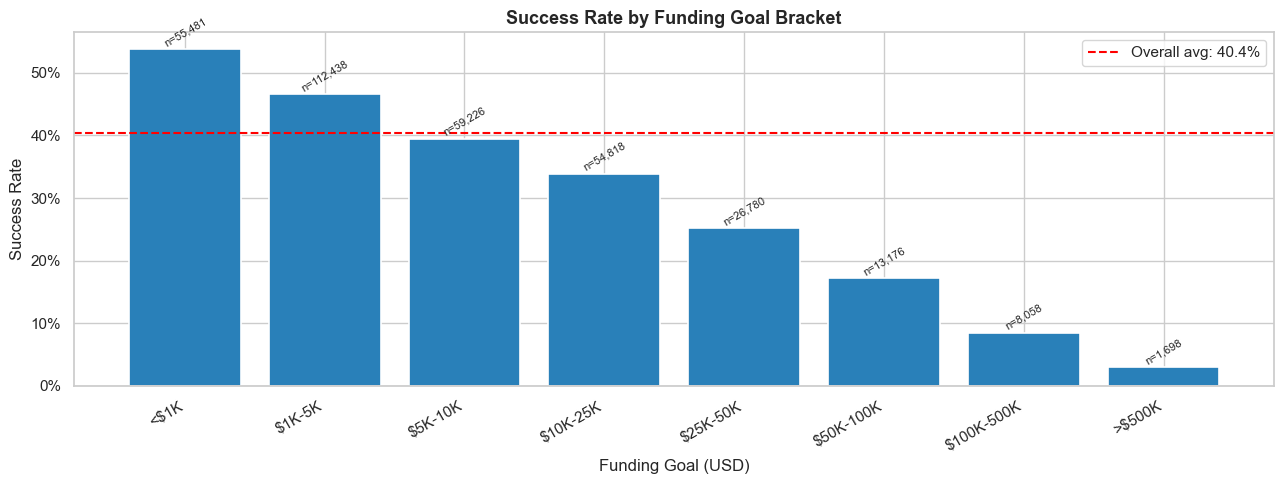

In [31]:
# ── Success rate by goal bracket ─────────────────────────────────────────────
bins   = [0, 1000, 5000, 10000, 25000, 50000, 100000, 500000, float('inf')]
labels = ['<$1K', '$1K-5K', '$5K-10K', '$10K-25K',
          '$25K-50K', '$50K-100K', '$100K-500K', '>$500K']

df['goal_bin'] = pd.cut(df['usd_goal_real'], bins=bins, labels=labels)
success_by_goal = df.groupby('goal_bin', observed=True)['target'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(range(len(success_by_goal)), success_by_goal['mean'].values,
              color='#2980b9', edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_title('Success Rate by Funding Goal Bracket', fontsize=13, fontweight='bold')
ax.set_xlabel('Funding Goal (USD)')
ax.set_ylabel('Success Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axhline(df['target'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {df["target"].mean():.1%}')
ax.legend()

# Add campaign count labels on bars
for i, (rate, count) in enumerate(zip(success_by_goal['mean'], success_by_goal['count'])):
    ax.text(i, rate + 0.005, f'n={count:,}', ha='center', fontsize=8, rotation=30)

plt.tight_layout()
plt.savefig('plots/05_success_by_goal.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['goal_bin'], inplace=True)


## Observations to remember
* ✅ Campaigns are grouped into meaningful funding ranges.
* ✅ Success rate is calculated for each funding bracket.
* ✅ The graph helps identify whether funding goal is predictive of success.
* ✅ Showing the number of campaigns (n=) prevents misleading conclusions from very small groups.
* ✅ Comparing each bracket with the overall success rate highlights which ranges perform above or below average.

---
## Section 10 — Categorical Feature Audit

**What:** Inspect the four categorical columns: `category`, `main_category`, `currency`, and `country`.  
**Why:** Categorical columns contain non-numeric text labels. Before encoding them, we need to understand:
1. How many unique values each column has (cardinality)
2. Whether any values are rare (< 0.1% of data) — rare categories can cause issues in OneHotEncoder
3. Whether the category a campaign belongs to predicts success differently

**What to look for:** High-cardinality columns (many unique values), rare categories, and strong success-rate differences between categories.


In [32]:
# ── Cardinality and null check ───────────────────────────────────────────────
cat_cols = CONFIG['categorical_cols']

print("── Categorical Column Summary ────────────────────────────")
for col in cat_cols:
    n_unique = df[col].nunique()
    n_null   = df[col].isnull().sum()
    print(f"  {col:<20} {n_unique:>4} unique values   {n_null:>5} nulls")
    print(f"\nTop categories in {col}")
    print(df[col].value_counts().head().to_string())


── Categorical Column Summary ────────────────────────────
  category              159 unique values       0 nulls

Top categories in category
category
Product Design    18680
Documentary       14523
Music             12633
Tabletop Games    11744
Shorts            11394
  main_category          15 unique values       0 nulls

Top categories in main_category
main_category
Film & Video    56527
Music           45949
Publishing      35445
Games           28521
Technology      27050
  currency               14 unique values       0 nulls

Top categories in currency
currency
USD    261511
GBP     29476
EUR     14378
CAD     12375
AUD      6621
  country                23 unique values       0 nulls

Top categories in country
country
US    261360
GB     29454
CA     12370
AU      6616
DE      3436
  launch_month           12 unique values       0 nulls

Top categories in launch_month
launch_month
7     32007
3     30100
10    29375
5     29175
6     28973
  launch_day_of_week      7 unique 

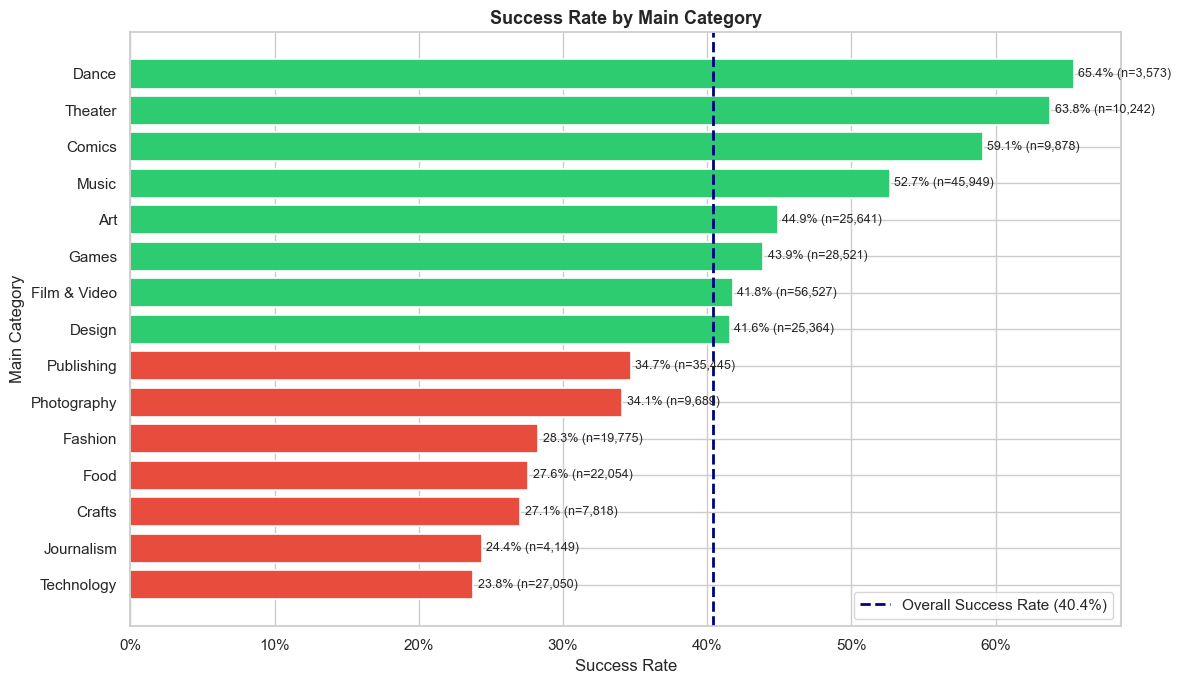

In [33]:
# ── Success rate by main_category ────────────────────────────────────────────
# Purpose:
#   Analyze whether project category influences campaign success.

# Calculate success statistics for each main category
main_cat_stats = (
    df.groupby("main_category", observed=True)["target"]
      .agg(
          success_rate="mean",
          campaigns="count"
      )
      .sort_values("success_rate")
)

overall_success = df["target"].mean()

# Assign colors based on overall success rate
colors = [
    "#2ecc71" if rate > overall_success else "#e74c3c"
    for rate in main_cat_stats["success_rate"]
]

# Plot

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    main_cat_stats.index,
    main_cat_stats["success_rate"],
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

# Overall average success rate
ax.axvline(
    overall_success,
    color="navy",
    linestyle="--",
    linewidth=2,
    label=f"Overall Success Rate ({overall_success:.1%})"
)

ax.set_title(
    "Success Rate by Main Category",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Success Rate")
ax.set_ylabel("Main Category")

ax.xaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)

ax.legend()

# Display success rate and sample size
for i, (rate, count) in enumerate(
    zip(
        main_cat_stats["success_rate"],
        main_cat_stats["campaigns"]
    )
):
    ax.text(
        rate + 0.003,
        i,
        f"{rate:.1%} (n={count:,})",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "plots/06_success_by_main_category.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

In [34]:
# ── Country distribution ─────────────────────────────────────────────────────
country_counts = df['country'].value_counts()
print("── Top 15 Countries ──────────────────────────────────────")
print(country_counts.head(15).to_string())

print()
rare_countries = country_counts[country_counts < 50]
print(f"  Countries with fewer than 50 campaigns: {len(rare_countries)}")
print(f"  {rare_countries.index.tolist()}")


── Top 15 Countries ──────────────────────────────────────
country
US    261360
GB     29454
CA     12370
AU      6616
DE      3436
FR      2520
NL      2411
IT      2369
ES      1873
SE      1509
MX      1411
NZ      1274
DK       926
IE       683
CH       652

  Countries with fewer than 50 campaigns: 1
  ['JP']


# Relationship Between Features and Campaign Success

After auditing and cleaning the dataset, the next step is to understand whether the engineered features have any relationship with campaign success.

Unlike the previous sections, which focused on data quality and distributions, the analyses below evaluate the **predictive value** of important features by comparing their success rates across different groups.

The objective is to answer the following questions:

- Does campaign duration influence success?
- Does the country where a campaign is launched affect its outcome?
- Does the launch month indicate seasonal trends in campaign performance?

These analyses help determine whether the selected features contain useful information for the machine learning model and provide business insights beyond simple data exploration.

## Campaign Duration vs Success

### Why is this analysis important?

Campaign duration is one of the most influential factors a project creator can control before launching a campaign.

By comparing success rates across different duration ranges, we can determine whether shorter or longer campaigns tend to perform better. This also helps validate whether **campaign_duration_days** should be retained as an important feature for the prediction model.

**Questions answered**

- Does campaign duration influence success?
- Which duration range performs best?
- Is campaign duration a useful predictive feature?

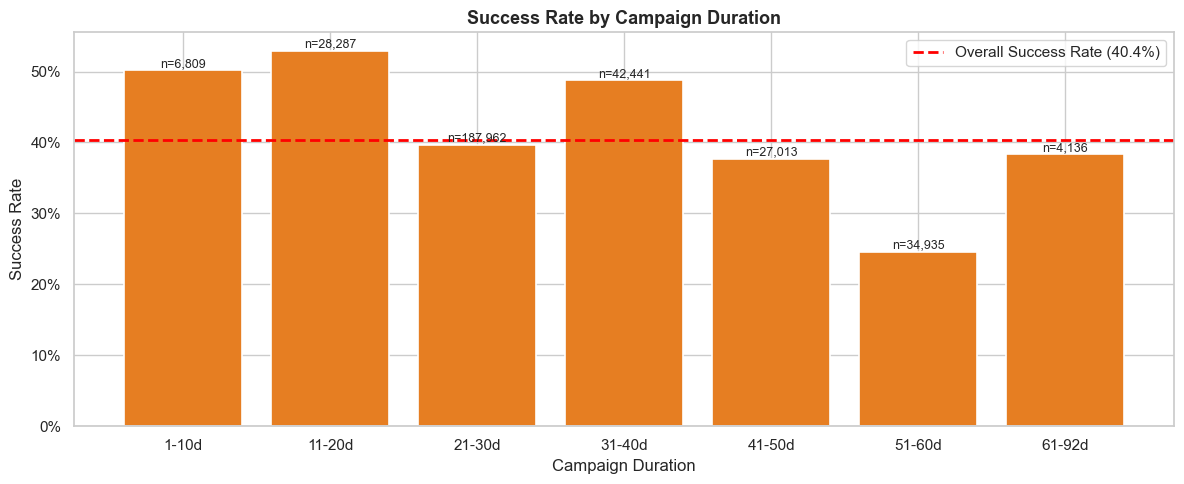

In [35]:

# Success Rate by Campaign Duration
# Purpose:
#   Analyze whether campaign duration influences campaign success.

overall_success = df["target"].mean()

dur_bins = [0, 10, 20, 30, 40, 50, 60, 92]
dur_labels = [
    "1-10d",
    "11-20d",
    "21-30d",
    "31-40d",
    "41-50d",
    "51-60d",
    "61-92d"
]

duration_bins = pd.cut(
    df["campaign_duration_days"],
    bins=dur_bins,
    labels=dur_labels
)

succ_by_dur = (
    df.groupby(duration_bins, observed=True)["target"]
      .agg(
          success_rate="mean",
          campaigns="count"
      )
)

fig, ax = plt.subplots(figsize=(12,5))

ax.bar(
    range(len(succ_by_dur)),
    succ_by_dur["success_rate"],
    color="#e67e22",
    edgecolor="white",
    linewidth=1.2
)

ax.set_xticks(range(len(dur_labels)))
ax.set_xticklabels(dur_labels)

ax.set_title(
    "Success Rate by Campaign Duration",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Campaign Duration")
ax.set_ylabel("Success Rate")

ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)

ax.axhline(
    overall_success,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall Success Rate ({overall_success:.1%})"
)

ax.legend()

for i, (rate, count) in enumerate(
    zip(
        succ_by_dur["success_rate"],
        succ_by_dur["campaigns"]
    )
):
    ax.text(
        i,
        rate + 0.005,
        f"n={count:,}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "plots/07_success_by_duration.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## Country vs Success

### Why is this analysis important?

Campaign performance may vary across countries due to differences in audience size, purchasing behavior, crowdfunding adoption, and economic conditions.

Comparing success rates across the most represented countries helps determine whether **country** contributes meaningful predictive information while avoiding conclusions based on countries with very few campaigns.

**Questions answered**

- Does campaign success vary by country?
- Which countries consistently perform above or below average?
- Is country a valuable feature for the model?

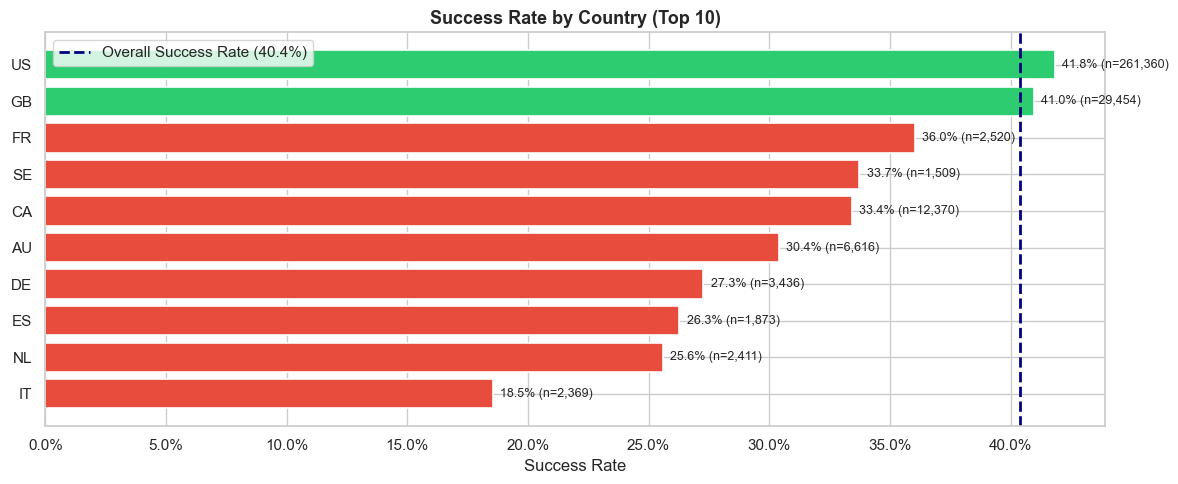

In [36]:
# Success Rate by Country
# Purpose:
#   Compare campaign success across the top 10 countries.

overall_success = df["target"].mean()

top10_countries = df["country"].value_counts().head(10).index

country_stats = (
    df[df["country"].isin(top10_countries)]
      .groupby("country", observed=True)["target"]
      .agg(
          success_rate="mean",
          campaigns="count"
      )
      .sort_values("success_rate")
)

colors = [
    "#2ecc71" if rate > overall_success else "#e74c3c"
    for rate in country_stats["success_rate"]
]

fig, ax = plt.subplots(figsize=(12,5))

ax.barh(
    country_stats.index,
    country_stats["success_rate"],
    color=colors,
    edgecolor="white",
    linewidth=1.2
)

ax.axvline(
    overall_success,
    color="navy",
    linestyle="--",
    linewidth=2,
    label=f"Overall Success Rate ({overall_success:.1%})"
)

ax.set_title(
    "Success Rate by Country (Top 10)",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Success Rate")

ax.xaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)

ax.legend()

for i, (rate, count) in enumerate(
    zip(
        country_stats["success_rate"],
        country_stats["campaigns"]
    )
):
    ax.text(
        rate + 0.003,
        i,
        f"{rate:.1%} (n={count:,})",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    "plots/08_success_by_country.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## Launch Month vs Success

### Why is this analysis important?

Campaigns launched during different months may experience seasonal effects such as holidays, consumer spending patterns, or increased online activity.

Analyzing monthly success rates helps identify whether launch timing influences campaign outcomes and whether **launch_month** should be included as a predictive feature.

**Questions answered**

- Does campaign success change throughout the year?
- Are there seasonal trends?
- Is launch month a useful feature for prediction?

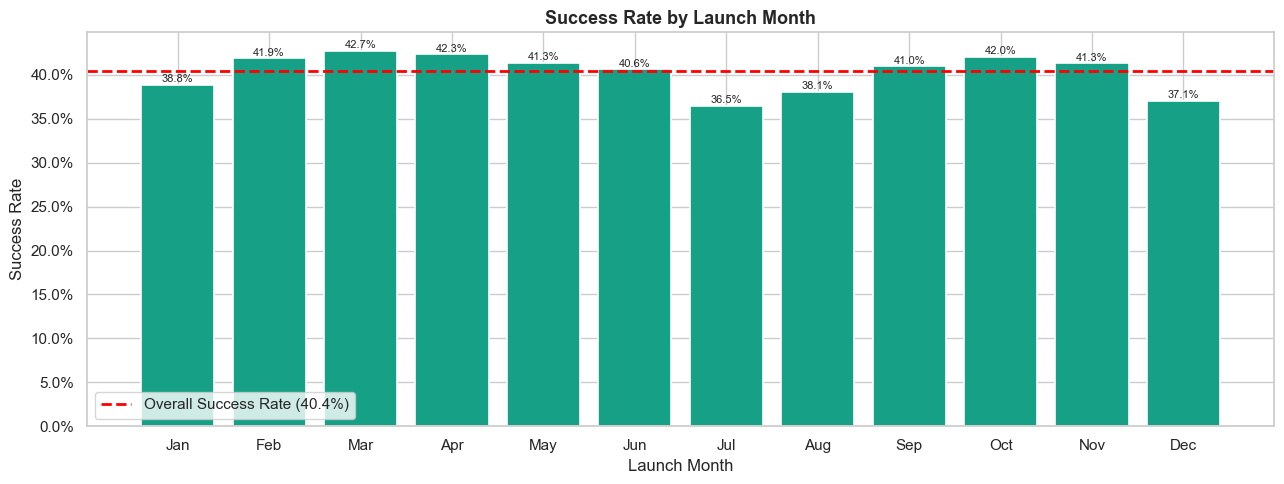

In [37]:
# Success Rate by Launch Month
# Purpose:
#   Check whether campaign success varies by launch month.

overall_success = df["target"].mean()

month_names = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

month_stats = (
    df.groupby(df["launched"].dt.month, observed=True)["target"]
      .agg(
          success_rate="mean",
          campaigns="count"
      )
)

fig, ax = plt.subplots(figsize=(13,5))

ax.bar(
    range(len(month_stats)),
    month_stats["success_rate"],
    color="#16a085",
    edgecolor="white",
    linewidth=1.2
)

ax.set_xticks(range(12))
ax.set_xticklabels(month_names)

ax.set_title(
    "Success Rate by Launch Month",
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel("Launch Month")
ax.set_ylabel("Success Rate")

ax.yaxis.set_major_formatter(
    mticker.PercentFormatter(1.0)
)

ax.axhline(
    overall_success,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Overall Success Rate ({overall_success:.1%})"
)

ax.legend()

for i, rate in enumerate(month_stats["success_rate"]):
    ax.text(
        i,
        rate + 0.003,
        f"{rate:.1%}",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.savefig(
    "plots/09_success_by_launch_month.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

---
## Section 11 — Final Clean Dataset Summary

**What:** Compile the full record of every cleaning decision made, verify the final dataset, and confirm it is ready for the feature engineering + model pipeline.  
**Why:** Proof of work. Before model building, we need to confirm that (1) no leakage columns remain, (2) all dates are valid, (3) all durations are realistic, (4) the target is binary, and (5) there are no nulls in any feature column we intend to use.

**What to look for:** All checks should pass (✅). Any ❌ means something was missed.


In [38]:
# ── STEP 1: Engineer date features FIRST ─────────────────────
# Why: These must exist before the checklist tries to verify them.
# launched carries useful time signals — extract as integers now
# so notebook 3 can use them without re-parsing dates.
df['launch_month']       = df['launched'].dt.month       # 1–12 seasonality
df['launch_day_of_week'] = df['launched'].dt.dayofweek   # 0=Mon 6=Sun
df['launch_year']        = df['launched'].dt.year        # platform growth trend

print("  ✅ Engineered: launch_month, launch_day_of_week, launch_year")

# ── STEP 2: Drop redundant columns ───────────────────────────
# goal  → mixed currencies, replaced by usd_goal_real
# state → string version of target, maximum leakage risk if left in
cols_to_drop = ['goal', 'state']
existing_cols = [col for col in cols_to_drop if col in df.columns]

if existing_cols:
    df.drop(columns=existing_cols, inplace=True)
    print(f"  ✅ Dropped: {', '.join(existing_cols)}")
else:
    print("  ℹ️  goal and state were already removed.")
    
# ── STEP 3: Final audit checklist ────────────────────────────
feature_cols = (CONFIG['numerical_cols'] +
                CONFIG['categorical_cols'] +
                [CONFIG['text_col']])

print("\n" + "=" * 60)
print("  FINAL DATASET AUDIT CHECKLIST")
print("=" * 60)

# Check 1: Shape
print(f"\n  ✅ Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Check 2: No leakage columns
leak_remaining = [c for c in CONFIG['leakage_cols'] if c in df.columns]
if len(leak_remaining) == 0:
    print("  ✅ No leakage columns present")
else:
    print(f"  ❌ Leakage columns still present: {leak_remaining}")

# Check 3: Target is binary
target_vals = df['target'].unique()
if set(target_vals) == {0, 1}:
    print("  ✅ Target is binary (0/1)")
else:
    print(f"  ❌ Target has unexpected values: {target_vals}")

# Check 4: No nulls in feature columns
null_check  = df[feature_cols].isnull().sum()
total_nulls = null_check.sum()
if total_nulls == 0:
    print("  ✅ Zero nulls in all feature columns")
else:
    print(f"  ❌ Nulls found:")
    print(null_check[null_check > 0])

# Check 5: Date validity
bad_dates = (df['launched'].dt.year < CONFIG['min_launch_year']).sum()
if bad_dates == 0:
    print(f"  ✅ All launch dates ≥ {CONFIG['min_launch_year']}")
else:
    print(f"  ❌ {bad_dates} corrupt dates remain")

# Check 6: Duration validity
bad_dur = (~df['campaign_duration_days'].between(
    CONFIG['min_duration_days'], CONFIG['max_duration_days'])).sum()
if bad_dur == 0:
    print(f"  ✅ All durations {CONFIG['min_duration_days']}–{CONFIG['max_duration_days']} days")
else:
    print(f"  ❌ {bad_dur} duration outliers remain")

# Check 7: Class balance
sr = df['target'].mean()
print(f"  ✅ Class balance: {sr:.1%} successful / {1-sr:.1%} failed")

# Check 8: New engineered columns present
new_cols     = ['launch_month', 'launch_day_of_week', 'launch_year']
missing_new  = [c for c in new_cols if c not in df.columns]
if not missing_new:
    print("  ✅ Date features engineered: launch_month, launch_day_of_week, launch_year")
else:
    print(f"  ❌ Missing date features: {missing_new}")

# Check 9: goal and state dropped
leaked_still = [c for c in ['goal', 'state'] if c in df.columns]
if not leaked_still:
    print("  ✅ Redundant columns dropped: goal, state")
else:
    print(f"  ❌ These should be dropped: {leaked_still}")

print()
print("=" * 60)
print("  CLEANING SUMMARY LOG")
print("=" * 60)
print(f"  Raw rows (2018 dataset)        : 378,661")
print(f"  After non-binary state filter  : 331,675  (canceled/live/etc removed)")
print(f"  After corrupt date filter      : 0 rows removed (dataset was clean)")
print(f"  After duration filter          : 0 rows removed (0-day campaigns retained)")
print(f"  Final rows                     : {df.shape[0]:,}")
print(f"  Leakage columns removed        : {len(CONFIG['leakage_cols'])}")
print(f"  Redundant columns dropped      : goal, state")
print(f"  Features engineered            : campaign_duration_days, name_length,")
print(f"                                   launch_month, launch_day_of_week,")
print(f"                                   launch_year, target")

# ── STEP 4: Save once ─────────────────────────────────────────
os.makedirs('data', exist_ok=True)
df.to_csv('Data/kickstarter_clean.csv', index=False)
print(f"\n  ✅ Saved → data/kickstarter_clean.csv")
print(f"     Shape   : {df.shape}")
print(f"     Columns : {df.columns.tolist()}")

  ✅ Engineered: launch_month, launch_day_of_week, launch_year
  ✅ Dropped: goal, state

  FINAL DATASET AUDIT CHECKLIST

  ✅ Final shape: 331,675 rows × 14 columns
  ✅ No leakage columns present
  ✅ Target is binary (0/1)
  ✅ Zero nulls in all feature columns
  ✅ All launch dates ≥ 2009
  ✅ All durations 0–92 days
  ✅ Class balance: 40.4% successful / 59.6% failed
  ✅ Date features engineered: launch_month, launch_day_of_week, launch_year
  ✅ Redundant columns dropped: goal, state

  CLEANING SUMMARY LOG
  Raw rows (2018 dataset)        : 378,661
  After non-binary state filter  : 331,675  (canceled/live/etc removed)
  After corrupt date filter      : 0 rows removed (dataset was clean)
  After duration filter          : 0 rows removed (0-day campaigns retained)
  Final rows                     : 331,675
  Leakage columns removed        : 5
  Redundant columns dropped      : goal, state
  Features engineered            : campaign_duration_days, name_length,
                             

---